[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


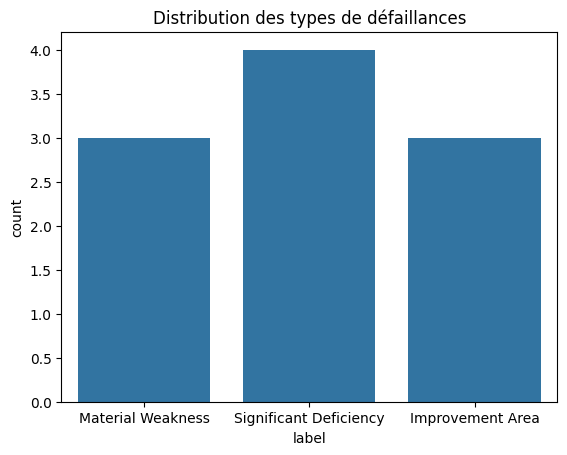

Accuracy : 0.3333333333333333
                        precision    recall  f1-score   support

      Improvement Area       0.00      0.00      0.00         1
     Material Weakness       0.00      0.00      0.00         1
Significant Deficiency       0.33      1.00      0.50         1

              accuracy                           0.33         3
             macro avg       0.11      0.33      0.17         3
          weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


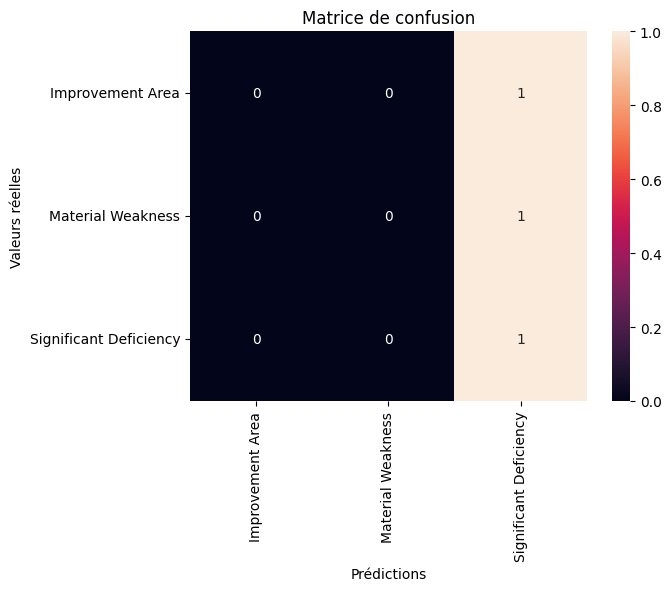

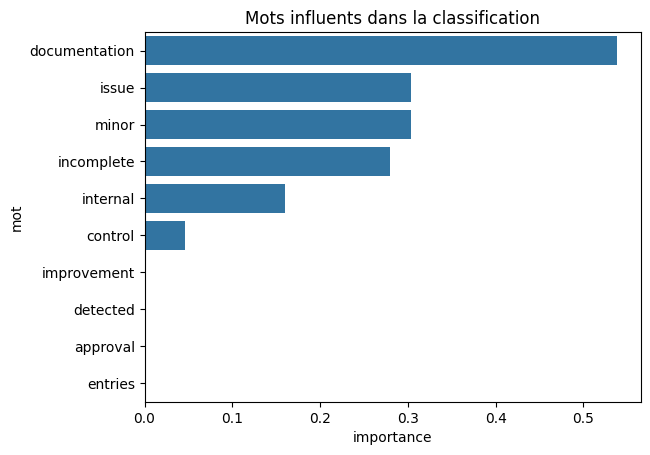

Type de défaillance prédit : Significant Deficiency


In [1]:
# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

nltk.download("stopwords")


# Chargement des données

data = {
    "description": [
        "Lack of segregation of duties in financial reporting process",
        "Missing approval for journal entries",
        "Failure to review reconciliation procedures",
        "Internal control documentation incomplete",
        "No monitoring of internal control effectiveness",
        "Process improvement recommended",
        "Minor issue in documentation",
        "Weak verification of financial transactions",
        "Incomplete audit trail detected",
        "Control review process missing"
    ],

    "label": [
        "Material Weakness",
        "Significant Deficiency",
        "Significant Deficiency",
        "Improvement Area",
        "Material Weakness",
        "Improvement Area",
        "Improvement Area",
        "Significant Deficiency",
        "Material Weakness",
        "Significant Deficiency"
    ]
}

df = pd.DataFrame(data)


# Exploration des données

plt.figure()
sns.countplot(x="label", data=df)
plt.title("Distribution des types de défaillances")
plt.show()


# Prétraitement du texte

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)


df["clean_text"] = df["description"].apply(clean_text)


# Transformation du texte en variables numériques

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]


# Séparation des données

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Entraînement du modèle de classification

model = LogisticRegression()

model.fit(X_train, y_train)


# Prédictions

y_pred = model.predict(X_test)


# Évaluation du modèle

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print(classification_report(y_test, y_pred))


# Matrice de confusion

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()


# Importance des variables

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

importance = pd.DataFrame({
    "mot": feature_names,
    "importance": coefficients
})

importance = importance.sort_values(by="importance", ascending=False).head(10)

plt.figure()
sns.barplot(x="importance", y="mot", data=importance)

plt.title("Mots influents dans la classification")
plt.show()


# Test sur une nouvelle description

example = "Lack of approval in financial reporting control"

example_clean = clean_text(example)

example_vec = vectorizer.transform([example_clean])

prediction = model.predict(example_vec)

print("Type de défaillance prédit :", prediction[0])